# Assignment 3 for 420-A14-AS

In this Assignment you'll translate mathematics from lecture into practical Numpy code. Specifically, you'll implement _linear least squares regression_ and _logistic regression_ "from scratch" and compare the results of your own implementations to those of *scikit-learn*, a popular machine learning package.

<span style="color:red">Warning:</span> Many of the code cells in this notebook use the same simple variable names like `X` or `y` but assign them to be different data. If you run cells out of order, you may get unexpected results. If you switch between sections, it's best to re-run the relevant cells.

**Run the code cell below** to import the required packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.linear_model

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

## 1. Logistic regression

Exercises 3.1&ndash;3.4 ask you to implement logistic regression, and to compare your results to applying the scikit-learn **[LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)** model.

<div style="border-bottom: 3px solid black;"></div>

### Part.1 &mdash; Vectorized code for generating predictions from a logistic model 

Recall from Lecture 1 that the logistic model has the form:
$$
\hat{y}(\mathbf{x}, \mathbf{w}) = \sigma(\mathbf{x}^T \mathbf{w})
$$

where $\mathbf{x}$ and $\mathbf{w}$ are the same as for Exercise 2.1 and $\sigma(\cdot)$ is the logistic sigmoid function described in Lecture 1.

**Write a function** that evaluates the logistic model in vectorized fashion, just like you did for Exercise 2.1.

In [2]:
def sigmoid(z):
    """Returns the element-wise logistic sigmoid of z."""
    # Your code here. Aim for 1 line.
    return 1/ (1+np.exp(-z))

    
def logistic_model_predict(X, w):
    """
    Returns predictions from logistic model y(x, w) at each point X[i,:] using parameters w.
    Given X with shape (N,D+1), w must have shape (D+1,) and the result will have shape (N,).
    """
    # Your code here. Aim for 1-2 lines.
    z = X @ w
    return sigmoid(z)

**Check your answer** by running the code cell below.

In [3]:
y = sigmoid(np.array([-1., 0., 1.5]))
assert isinstance(y, np.ndarray), "Expected an ndarray!"
assert np.allclose(y, [0.26894142, 0.5, 0.81757448]), "Values from sigmoid() appear to be wrong!"
w = np.array([2, 1.5])                           # Parameters corresponding to logistic model y = sigmoid(2 + 1.5*x1)
X = np.array([[1., -2.], [1.,  0.], [1.,  2.]])  # Evaluate at x1 = -2, 0, 2
y = logistic_model_predict(X, w)                 # Predict y for all X using w
assert isinstance(y, np.ndarray), "Expected an ndarray!"
assert np.allclose(y, [0.26894142, 0.88079708, 0.99330715]), "Wrong returned!\n%s" % y
try:
    y = logistic_model_predict(X, w.reshape(-1, 1))
except ValueError:
    raise AssertionError("Your answer works when 'w' is 1-dimensional, but not when it is a column vector. Try again.")
w = np.array([1, 0.5, 0.25])                      # Parameters corresponding to the 2D plane y = 1 + 0.5*x1 + 0.25*x2
X = np.array([[1., -3., 1.], [1.,  3., 0.], [1.,  5., -2.]])   # Evaluate at different (x1, x2) points
y = logistic_model_predict(X, w)                  # Predict y for all X using w
assert np.allclose(y, [0.4378235, 0.92414182, 0.95257413]), "Wrong predictions for 2-dimensional feature space!\n%s" % y
print("Correct!")

Correct!


![image](img/d1.png)

**Plot several predictions at once** by running the code cell below.

In [4]:
# Parameters corresponding to logistic model y = sigmoid(2 + 1.5*x1)
# A column of 1s so that the bias term w[0] gets added
# A column of x values ranging from [-5, 5]
# A 20x2 matrix where X[i,:] is the ith x vector
# Evaluate all x values
x = np.linspace(-5,5,20)
X = np.stack([np.ones_like(x), x], axis=1)
w = np.array([2, 1.5])
y = logistic_model_predict(X, w)
y.shape
# _ = np.hstack([X, y[:,None]])
# _


(20,)

<div style="border-bottom: 3px solid black;"></div>

### Part 1.2 &mdash; Logistic regression by gradient descent

Recall from Lecture 1 that the basic logistic regression training objective (learning objective) is:

$$
\ell_\text{LR}(\mathbf{w}) = \sum_{i=1}^N y_i \ln \sigma(\mathbf{w}^T \mathbf{x}_i) + (1-y_i) \ln \left(1-\sigma(\mathbf{w}^T \mathbf{x}_i)\right)
$$

The "basic" gradient for the above training objective is on a slide titled "Maximum likelihood estimate for LR" from Lecture 1, and reproduced here:

$$
\nabla \ell_\text{LR}(\mathbf{w}) = \sum_{i=1}^N (\sigma(\mathbf{w}^T \mathbf{x}_i) - y_i)\mathbf{x}_i
$$

**Write a function** to implement logistic regression by gradient descent. Your answer to _logistic_regression_grad_ should ideally be fully vectorized (no for-loops), but this may take a while to figure out. If you can't figure out the vectorization, it's OK &mdash; just compute the gradient however you can. Your answer to _logistic_regression_ should use your _logistic_regression_grad_ function to compute the gradient at each step.

Implementing _logistic_regression_grad_ is the hardest exercise in this lab because a vectorized implementation requires using the `@` matrix multiply operator to compute all the $\mathbf{w}^T \mathbf{x}$ products, reshaping the vector of residuals into a column-vector to use Numpy's broadcasting feature, and then summing over a specific axis (over training cases $i=1,\ldots,N$).

In [5]:
def logistic_regression_grad(X, y, w):
    """Returns the gradient for basic logistic regression."""
    # Your code here. Aim for 1-3 lines.
    y_hat = logistic_model_predict(X, w)
    delta = y_hat - y
    return X.T @ delta


def logistic_regression(X, y, w_init, learn_rate=0.05, num_steps=500):
    """
    Fits a logistic model by gradient descent.
    
    If the feature matrix X has shape (N,D) the targets y should have shape (N,)
    and the initial parameters w_init should have shape (D,).
    
    Returns a new parameter vector w that minimizes the negative log likelihood of the targets.
    """
    # Your code here. Aim for 4-5 lines.
    for step in range(num_steps):
        grad = logistic_regression_grad(X, y, w_init)
        w_init -= learn_rate * grad
    return w_init

**Check your answer** by running the code cell below.

In [6]:
X = np.array([[1, -1.0], [1, 1.0], [1, 2.0]])
y = np.array([0.0, 0.0, 1.0])
grad = logistic_regression_grad(X, y, np.array([0.0, 1.0]))
assert isinstance(grad, np.ndarray), "Expected ndarray from logistic_regression_grad!"
assert grad.shape == (2,), "Expected gradient to have shape (2,) but was %s" % (grad.shape,)
assert np.allclose(grad, [0.88079708, 0.22371131]), "Wrong value for gradient!"
grad = logistic_regression_grad(X, y, np.array([-1.0, 1.5]))
assert np.allclose(grad, [0.57911459, 0.30819531]), "Wrong value for gradient!"
w = logistic_regression(X, y, np.array([1.0, 0.0]))
assert isinstance(w, np.ndarray), "Expected ndarray from logistic_regression!"
assert w.shape == (2,), "Expected parameter vector w to have shape (2,) but was %s" % (w.shape,)
assert np.allclose(w, [-4.14100532, 2.95489589]), "Parameters found by gradient descent seem wrong!"
print("Correct!")

Correct!


### Part 1.3 &mdash; Run logistic regression on data and plot the result

For this exercise you'll need to define Numpy arrays that correspond to the following training data:

$$
X = \begin{bmatrix}
1 & -4.1\\
1 & -2.8\\
1 & -0.7\\
1 &  3.5
\end{bmatrix}, \quad
\mathbf{y} = \begin{bmatrix}
0 \\
0\\
1\\
1
\end{bmatrix}
$$

**Write code** to create the following plot:
![image](img/fig-logistic-regression-1d-train-and-test.png)

Your code should follow this sequence of steps, which are the same as for Exercise 2.4:
1. Make ndarrays $X$ and $\mathbf{y}$ that contain the above training set.
2. Plot the training set in blue. Use the $x$ coordinates from the second column of $X$, ignoring the first column.
3. Run logistic regression on $(X, \mathbf{y})$ to get fitted parameters $\mathbf{w}$; use your *logistic_regression* function, starting from $\mathbf{w}_\text{init} = \begin{bmatrix} 0.0, 1.0 \end{bmatrix}^T$
4. Define a "test set" of 20 equally-spaced values of $x$ in range $[-5, 5]$. You will need to build a new matrix $X_\text{test}$ with $1$ in the first column and the 20 distinct $x$ values in the second column.
5. Predict 20 $y$ values corresponding to the 20 rows of $X_\text{test}$ by applying a logistic model with your fitted parameters $\mathbf{w}$. Do this with single call to your *logistic_model_predict* function. 
6. Plot the predictions on the test set.

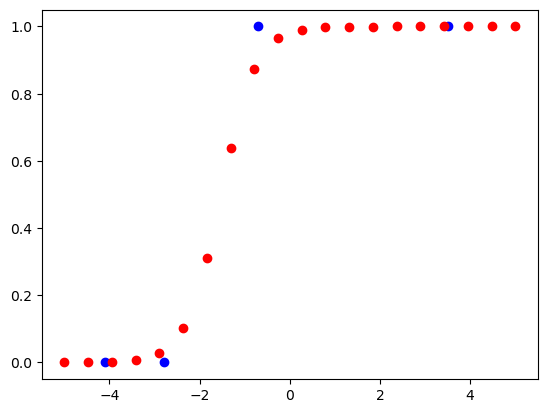

In [7]:
# 1. Define the training set. Aim for 2 lines.
X = np.stack([np.ones(4), np.array([-4.1,-2.8,-0.7,3.5])], axis=1)
y = np.array([0, 0, 1, 1])

# 2. Plot the training set. Aim for 1 line.
plt.scatter(X[:,1], y, color='blue', label='Training data')

# 3. Run logistic regression on the training set to get 'w'. Aim for 1-2 lines.
w_init = np.array([0.0, 1.0])
w = logistic_regression(X, y, w_init)

# 4. Define the test set matrix of shape (20,2). Aim for 1-3 lines.
x_test = np.linspace(-5, 5, 20)
X_test = np.stack([np.ones_like(x_test), x_test], axis=1)

# 5. Use the linear model to make predictions on the test set. Aim for 1 line.
y_test = logistic_model_predict(X_test, w)


# 6. Plot the test predictions. Aim for 1 line, plus a few lines to configure the plot (axis labels etc).
plt.scatter(X_test[:,1], y_test, color='red', label='Test predictions')



<div style="border-bottom: 3px solid black;"></div>

### Part 1.4 &mdash; Run scikit-learn LogisticRegression

The scikit-learn package provides a **[LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)** object to perform logistic regression.

**Write code to fit a LogisticRegression model** using the same training matrix $X$ that you defined as part of Exercise 3.3. There are only two steps:
1. Create the _LogisticRegression_ object. Use the *fit_intercept=False*, *penalty='none'*, and *solver='lbfgs'* options when creating the *LogisticRegression* object (see [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)). (L-BFGS is a more powerful gradient-based solver than mere gradient descent.)
2. Fit the _LogisticRegression_ object to the training matrix $X$ and targets $\mathbf{y}$. Use the object's **[fit](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit)** method.

The variable holding a reference to your _LogisticRegression_ object should be called `model`, so that your answer can be checked.

A tweet regarding the fact that scikit-learn's LogisticRegression object applies regularization (a weight penalty) "by default":
![image](img/fig-logistic-regression-regularization-tweet.png)

In [20]:
# Your code here. Aim for 2 lines.
logistic_model = sklearn.linear_model.LogisticRegression(fit_intercept=False,penalty= None, solver='lbfgs')
logistic_model.fit(X,y)
logistic_model.coef_

array([[16.28329414,  9.1756528 ]])

**Check your answer** by running the code cell below.

In [12]:
assert 'logistic_model' in globals(), "You didn't create a variable named 'logistic_model'!"
assert isinstance(logistic_model, sklearn.linear_model.LogisticRegression), "Expected a LogisticRegression instance!"
assert hasattr(logistic_model, 'coef_'), "No model coefficients yet! You didn't fit the model to any data!"
assert logistic_model.intercept_ == 0.0, "You forgot to disable fitting of the intercept!"
assert np.allclose(logistic_model.coef_, [[18.5251137, 10.49283446]]), "The parameters seem incorrect! Not L-BFGS?"
print("Correct!")

AssertionError: The parameters seem incorrect! Not L-BFGS?

Notice that the model parameters (coefficients) found by the _LogisticRegression_ are much larger than those found by your gradient descent solver. That is only because scikit-learn uses a more powerful optimization algorithm and can learn very sharp decision boundaries in fewer steps than mere gradient descent can. If you increase your *num_steps* argument your solver will find similarly large coefficients.

![image](img/d2.png)

**Plot several LogisticRegression predictions at once** by running the code cell below.

[0 1]


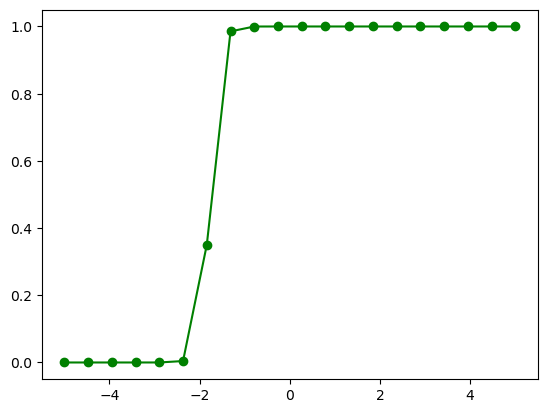

In [19]:
# A column of 1s so that the bias term w[0] gets added
# A column of x values ranging from [-5, 5]
# A 20x2 matrix where X[i,:] is the ith x vector
# Evaluate all x values and get two probabilities back (class 0, class 1)
# Plot probability of class 1 only
x = np.linspace(-5,5,20)
X_test = np.stack([np.ones_like(x), x], axis=1)
probabilities = logistic_model.predict_proba(X_test)

print(logistic_model.classes_)

plt.scatter(x, probabilities[:,1], color='green', label='Probability of class 1')
plt.plot(x, probabilities[:,1], color='green')



## Deliverable
###### 1)	Create one zip file, containing the necessary source-code files;
###### 2)	You must name your file using the following convention:  Your file should be called A#_studentID, where # is the number of the assignment.
###### 3)	Assignments must be submitted in the assignment section in OMNIVOX.
###### 4)	You submit your assignment by 19-July-2026 at 23:55.
